<h1 style="color: orange; font-size: 40px; font-weight: bold;">
LAB 6
</h1>

<h2 style="color: green; font-size: 35px; font-weight: bold;">
1D Ising Model
</h2>

Ising model consist of a discrete lattice filled with spins, modelled as variables which can take only binary values $\pm1$. It was developed to model magnetic materials, but it can be used in a plenty of applications.
The hamiltonian of the system depends on the alignement between spin and on a coupling with external field
$$
H=-J\sum_{<i,j>}s_is_j-h\sum_i s_i.
$$

However, only for the 1D and 2D cases, one can compute the partition function, from which one can extract all the termodynamics property. For the one-dimensional case the partition function is given by
$$
Z=\lambda_1^N+\lambda_2^N,
$$
where
$$
\lambda_{1, 2}=e^{\beta J}cosh(\beta J)\pm\big[e^{2\beta J}cosh^2(\beta h)-2sinh(2\beta J)\big]^{1/2}
$$
To compute the quantities of interest (total energy, magnetization, magnetic susceptibility, and specific heat), we first calculate the average of the corresponding observables. The susceptibility and the specific heat are then evaluated using the corresponding fluctuation formulas.
For example, the susceptibility is obtained via
$$
\chi(N, T) = \frac{\partial M}{\partial h}=\beta\bigg[\langle\bigg(\sum_{i=1}^Ns_i\bigg)^2\rangle-\langle\sum_{i=1}^Ns_i\rangle^2\bigg]_{h=0}=\beta\bigg[\langle\bigg(\sum_{i=1}^Ns_i\bigg)^2\rangle\bigg]
$$

The one-dimensional Ising model does not exhibit spontaneous magnetization in the absence of an external magnetic field. Consequently, no phase transition occurs at finite temperature. For this reason, the magnetization is computed by introducing a weak external field.

Moreover, unlike the Metropolis algorithm used in continuous systems, the Metropolis algorithm for the Ising model does not provide a tunable proposal step to achieve an acceptance rate of approximately (50%), since the only possible move is to flip of a single spin. As a consequence, the efficiency of the algorithm decreases at low temperatures, where proposed moves are more likely to be rejected.

To avoid introducing more sophisticated update schemes, the analysis is restricted to temperatures above $T=0.5$. In addition, the sampling is improved at low temperatures by increasing the number of Monte Carlo steps per block. More precisely, the number of steps is chosen according to the power law

$$
N_{\mathrm{step}}(T)=N_0\left(\frac{T_{\max}}{T}\right),
$$

where $N_0$ is the number of Monte Carlo steps performed at the maximum temperature.

This choice provides a more accurate sampling in the low-temperature region by allowing the system to perform a larger number of Monte Carlo moves. The acceptance rate is reported for both $h=0$ and $h=0.02$.


The imput parameter for the Metropolis simulation are:

In [17]:
import pandas as pd

dati = {
    "-": ["SIMULATION_TYPE", "RESTART", "RHO", "NPART", "NBLOCKS", "NSTEPS"],
    ".": [2, 0, 50, 1.0, 20, 20000],
    "J": [1.0, None, None, None, None, None],
    "H": [0.0, None, None, None, None, None]
}

df = pd.DataFrame(dati)

df

,-,.,J,H
0,SIMULATION_TYPE,2.0,1.0,0.0
1,RESTART,0.0,NaN,NaN
2,RHO,50.0,NaN,NaN
3,NPART,1.0,NaN,NaN
4,NBLOCKS,20.0,NaN,NaN
5,NSTEPS,20000.0,NaN,NaN


where H is set to 0.02 to compute the magnetization. When Gibbs sampling is used, only the simulation type is changed to 3, while all the other parameters remain unchanged. In the range of temperature we have worked, at the lowest temperature we have 6 times number of step than the max temperature.

In [18]:
import numpy as np
import matplotlib.pyplot as plt

J = 1.0
Ns = 50
def Teo_Energy(T):
   beta = 1/T
   th = np.tanh(J/T)
   thN= th**Ns
   ch = 1/th
   return -J*( th + ch*thN )/( 1 + thN )

def Teo_chi(T):
   beta = 1/T
   th = np.tanh(J/T)
   thN= th**Ns
   ch = 1/th
   return beta*np.exp(2*beta*J)*(1-thN)/(1+thN)

def Teo_Mag(T):
   h=0.02 #external field
   b = 1/T

   l1 = np.exp(b*J)*np.cosh(b*h)+np.sqrt(np.exp(2*b*J)*np.cosh(b*h)*np.cosh(b*h)-2*np.sinh(2*b*J))
   l2 = np.exp(b*J)*np.cosh(b*h)-np.sqrt(np.exp(2*b*J)*np.cosh(b*h)*np.cosh(b*h)-2*np.sinh(2*b*J))
   Z = l1**Ns + l2**Ns
   return (np.exp(b*J)*np.sinh(b*h)*((l1**(Ns-1))*(1+np.exp(b*J)*np.cosh(b*h)/np.sqrt(np.exp(2*b*J)*np.cosh(b*h)*np.cosh(b*h)-2*np.sinh(2*b*J))) 
        + (l2**(Ns-1))*(1-np.exp(b*J)*np.cosh(b*h)/np.sqrt(np.exp(2*b*J)*np.cosh(b*h)*np.cosh(b*h)-2*np.sinh(2*b*J)))))/(Z)

def Teo_Cv(T):
   beta = 1/T
   th = np.tanh(J/T)
   thN= th**Ns
   ch = 1/th
   return ((beta*J)**2)*(((1+thN+(Ns-1)*(th**2)+(Ns-1)*(ch**2)*thN)/(1+thN))-Ns*((th+ch*thN)/(1+thN))**2)

In [19]:
def plot_chi(ax, T, chi, err, color, label, teo=False):
    ax.errorbar(T,chi, yerr=err, capsize=0.5,alpha=0.7, fmt='--',color=color,label=label)
    ax.set_xlabel("T")
    ax.set_ylabel(r"<$\chi$>")
    ax.set_title("average susceptibility")
    ax.grid(True)
    if teo:
        Chi_teo=Teo_chi(T)
        ax.plot(T,Chi_teo, color="black",ls='--', lw=2, label="Theory")
    ax.legend()
def plot_E(ax, T,E,err, color, label, teo=False):
    ax.errorbar(T,E, yerr=err,capsize=0.5,alpha=0.8, color=color,fmt= '--',label=label)
    ax.set_xlabel("T")
    ax.set_ylabel("<E>")
    ax.set_title("average total energy")
    ax.grid(True)
    if teo:
        E_teo=Teo_Energy(T)
        ax.plot(T,E_teo, color="black",ls='--', lw=2, label="Theory")
    ax.legend()
def plot_cv(ax, T, cv, err, color, label, teo=False):
    ax.errorbar(T,cv, yerr=err,capsize=0.5,alpha=0.7, fmt='--',color=color,label=label)
    ax.set_xlabel("T")
    ax.set_ylabel(r"<$c_v$>")
    ax.set_title("average specific heat")
    ax.grid(True)
    if teo:
        Cv_teo=Teo_Cv(T)
        ax.plot(T,Cv_teo, color="black",ls='--', lw=2, label="Theory")
    ax.legend()
def plot_M(ax, T, M, err, color, label, teo=False):
    ax.errorbar(T,M, yerr=err,capsize=0.5,alpha=0.7, fmt='--',color=color,label=label)
    ax.set_xlabel("T")
    ax.set_ylabel("<M>")
    ax.set_title("average magnetization")
    ax.grid(True)
    if teo:
        Cv_teo=Teo_Mag(T)
        ax.plot(T,Cv_teo, color="black",ls='--', lw=2, label="Theory")
    ax.legend()
def plot_A(ax, n, a, color, h):
    ax.plot(n,a, '-o', color=color, alpha=0.7)
    ax.grid(True)
    ax.set_xlabel("T")
    ax.set_ylabel("A")
    ax.set_title(f" acceptance with h={h}")


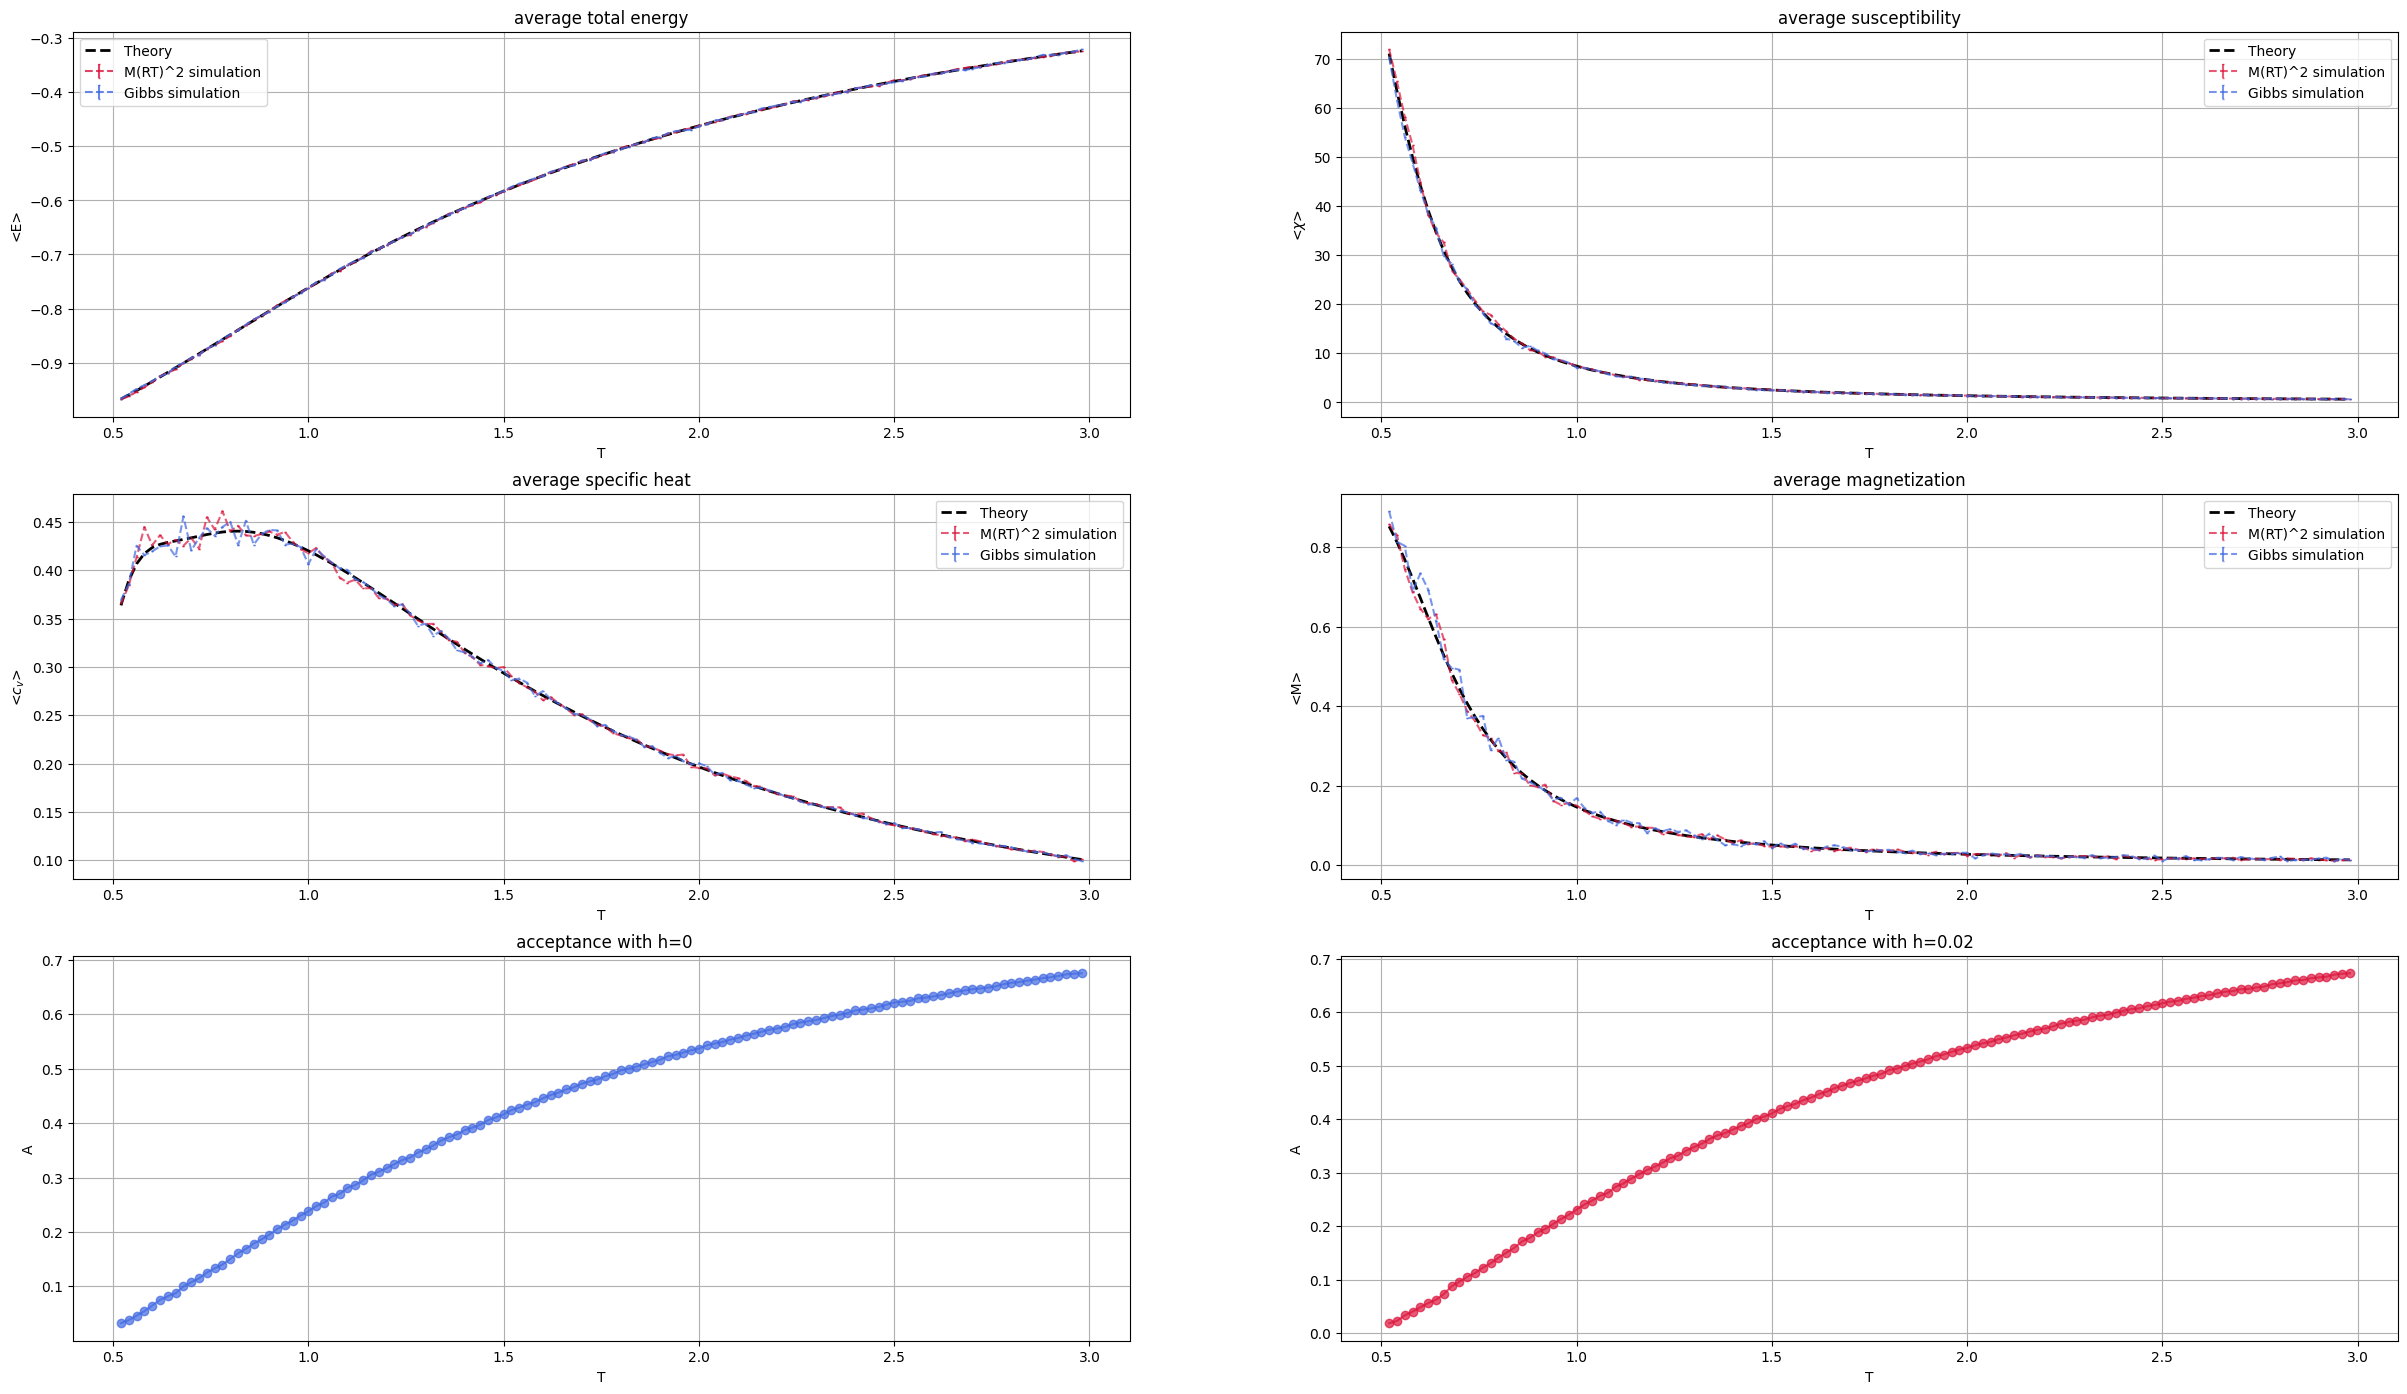

In [20]:
#load data
energiesM=np.loadtxt("./NSL_SIMULATOR/OUTPUT/total_energy_Metro.dat", skiprows=1)
susceptibilityM=np.loadtxt("./NSL_SIMULATOR/OUTPUT/susceptibility_Metro.dat", skiprows=1)
specific_heatM=np.loadtxt("./NSL_SIMULATOR/OUTPUT/specific_heat_Metro.dat", skiprows=1)
magnetizationM=np.loadtxt("./NSL_SIMULATOR/OUTPUT/magnetization_Metro.dat", skiprows=1)
energiesG=np.loadtxt("./NSL_SIMULATOR/OUTPUT/total_energy_Gibbs.dat", skiprows=1)
susceptibilityG=np.loadtxt("./NSL_SIMULATOR/OUTPUT/susceptibility_Gibbs.dat", skiprows=1)
specific_heatG=np.loadtxt("./NSL_SIMULATOR/OUTPUT/specific_heat_Gibbs.dat", skiprows=1)
magnetizationG=np.loadtxt("./NSL_SIMULATOR/OUTPUT/magnetization_Gibbs.dat", skiprows=1)
A00=np.loadtxt("./NSL_SIMULATOR/OUTPUT/acceptance_Metro00.dat", skiprows=1)
A02=np.loadtxt("./NSL_SIMULATOR/OUTPUT/acceptance_Metro02.dat", skiprows=1)

indices = np.arange(20, len(energiesM), 20)

T = energiesM[indices, 0]
EM = energiesM[indices, 3]
err_EM = energiesM[indices, 4]
chiM = susceptibilityM[indices, 3]
err_chiM = susceptibilityM[indices, 4]
cvM = specific_heatM[indices, 3]
err_cvM = specific_heatM[indices, 4]
MM = magnetizationM[indices, 3]
err_MM = magnetizationM[indices, 4]
EG = energiesG[indices, 3]
err_EG = energiesG[indices, 4]
chiG = susceptibilityG[indices, 3]
err_chiG = susceptibilityG[indices, 4]
cvG = specific_heatG[indices, 3]
err_cvG = specific_heatG[indices, 4]
MG = magnetizationG[indices, 3]
err_MG = magnetizationG[indices, 4]
A0=A00[indices,1]
A02=A02[indices,1]
n=A00[indices,0]

#plot
fig, ax=plt.subplots(3,2, figsize=(30,17))
ax=ax.flatten()

plot_E(ax[0],T, EM, err_EM,"crimson", "M(RT)^2 simulation", True)
plot_E(ax[0],T, EG, err_EG,"royalblue", "Gibbs simulation")
plot_chi(ax[1],T, chiM, err_chiM,"crimson", "M(RT)^2 simulation", True)
plot_chi(ax[1],T, chiG, err_chiG,"royalblue", "Gibbs simulation")
plot_cv(ax[2],T, cvM, err_cvM, "crimson", "M(RT)^2 simulation", True)
plot_cv(ax[2],T, cvG, err_cvG,"royalblue", "Gibbs simulation")
plot_M(ax[3],T, MM, err_MM, "crimson", "M(RT)^2 simulation", True)
plot_M(ax[3],T, MG, err_MG,"royalblue", "Gibbs simulation")
plot_A(ax[4], T, A0, "Royalblue", 0)
plot_A(ax[5], T, A02, "crimson", 0.02)

plt.show()